# 1. EDA Phase

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)

In [3]:
data_path = Path("bci2a/patients/patients/BCICIV_2a_1.csv")

df = pd.read_csv(data_path)

print(df.shape)

df.head()

(57888, 26)


,patient,time,label,epoch,EEG-Fz,EEG-0,EEG-1,EEG-2,EEG-3,EEG-4,...,EEG-8,EEG-9,EEG-10,EEG-11,EEG-12,EEG-13,EEG-14,EEG-Pz,EEG-15,EEG-16
0,1,-0.100,tongue,8,-1.681412,2.245496,-0.158350,1.163765,-1.523659,-0.575267,...,0.758116,3.441785,0.305517,1.137473,-1.275763,-2.898359,0.656704,-2.010063,-1.613804,-1.942455
1,1,-0.096,tongue,8,0.420417,0.587559,1.650510,0.970672,1.505904,0.891796,...,1.541586,-0.071620,0.258909,-1.448198,0.142472,-1.968405,-1.733655,-2.935578,-3.125256,-4.674610
2,1,-0.092,tongue,8,0.551365,1.499758,0.121302,2.859433,2.613414,4.636026,...,2.649097,-2.137938,-1.612096,-1.610218,-0.410173,-0.274957,-4.776535,-5.099551,-2.798995,-5.862021
3,1,-0.088,tongue,8,3.054916,-1.807238,1.843603,2.286812,5.995872,6.651295,...,6.031554,-5.249621,-2.672998,-3.452370,0.189081,1.593829,-6.081577,-5.476860,-2.932163,-6.874095
4,1,-0.084,tongue,8,2.506710,-2.453101,0.221178,0.127278,4.519931,6.249573,...,7.827097,-5.309546,-2.488783,-3.707608,1.447515,4.268278,-4.383690,-4.218426,-1.331932,-5.322692


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57888 entries, 0 to 57887
Data columns (total 26 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   patient  57888 non-null  int64  
 1   time     57888 non-null  float64
 2   label    57888 non-null  str    
 3   epoch    57888 non-null  int64  
 4   EEG-Fz   57888 non-null  float64
 5   EEG-0    57888 non-null  float64
 6   EEG-1    57888 non-null  float64
 7   EEG-2    57888 non-null  float64
 8   EEG-3    57888 non-null  float64
 9   EEG-4    57888 non-null  float64
 10  EEG-5    57888 non-null  float64
 11  EEG-C3   57888 non-null  float64
 12  EEG-6    57888 non-null  float64
 13  EEG-Cz   57888 non-null  float64
 14  EEG-7    57888 non-null  float64
 15  EEG-C4   57888 non-null  float64
 16  EEG-8    57888 non-null  float64
 17  EEG-9    57888 non-null  float64
 18  EEG-10   57888 non-null  float64
 19  EEG-11   57888 non-null  float64
 20  EEG-12   57888 non-null  float64
 21  EEG-13   57888 non-null

In [5]:
df.describe()

,patient,time,epoch,EEG-Fz,EEG-0,EEG-1,EEG-2,EEG-3,EEG-4,EEG-5,...,EEG-8,EEG-9,EEG-10,EEG-11,EEG-12,EEG-13,EEG-14,EEG-Pz,EEG-15,EEG-16
count,57888.0,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,...,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000,57888.000000
mean,1.0,0.300000,305.260417,-0.305020,-0.043882,-0.239512,-0.381103,-0.353202,-0.260120,0.305820,...,-0.030301,0.469864,0.169012,-0.107572,-0.109945,-0.046082,0.755006,0.360044,0.276671,0.468113
std,0.0,0.232094,171.959384,6.273783,4.730638,4.697771,5.166788,4.551098,5.044783,5.450873,...,5.935352,4.420768,3.041792,3.226786,2.874301,4.221780,5.069249,4.607678,4.886943,7.316493
min,1.0,-0.100000,8.000000,-38.846615,-25.083998,-23.036546,-25.675570,-21.760186,-29.875898,-26.333469,...,-27.089536,-23.176201,-13.457356,-14.030659,-12.858357,-29.609819,-21.806624,-19.687551,-25.045840,-33.882194
25%,1.0,0.100000,157.500000,-4.084767,-3.131786,-3.258381,-3.639659,-3.235568,-3.408920,-3.263930,...,-3.851852,-2.327168,-1.769529,-2.197436,-1.963027,-2.665081,-2.477408,-2.603790,-2.873518,-4.222395
50%,1.0,0.300000,306.500000,-0.243415,-0.042170,-0.204660,-0.317383,-0.289341,-0.175209,0.278286,...,-0.044731,0.530622,0.147978,-0.111571,-0.075291,-0.013189,0.728623,0.342480,0.273207,0.439026
75%,1.0,0.500000,453.500000,3.551456,3.046316,2.812440,2.926700,2.580123,2.973415,3.859833,...,3.804326,3.348397,2.091607,1.985051,1.747868,2.647603,3.984123,3.304435,3.427743,5.143941
max,1.0,0.700000,602.000000,36.211774,21.596970,21.547459,23.416074,21.228198,23.268565,31.755269,...,32.451496,19.229403,23.932952,13.834579,13.997880,26.793324,24.765762,21.846488,25.416576,35.077801


In [6]:
df.columns.tolist()

['patient',
 'time',
 'label',
 'epoch',
 'EEG-Fz',
 'EEG-0',
 'EEG-1',
 'EEG-2',
 'EEG-3',
 'EEG-4',
 'EEG-5',
 'EEG-C3',
 'EEG-6',
 'EEG-Cz',
 'EEG-7',
 'EEG-C4',
 'EEG-8',
 'EEG-9',
 'EEG-10',
 'EEG-11',
 'EEG-12',
 'EEG-13',
 'EEG-14',
 'EEG-Pz',
 'EEG-15',
 'EEG-16']

In [7]:
print("Missing values:", df.isnull().sum().sum())

print("Epochs:", df["epoch"].nunique())

print(df["label"].value_counts())

print(df["time"].min(), df["time"].max())

Missing values: 0
Epochs: 288
label
tongue    14472
foot      14472
right     14472
left      14472
Name: count, dtype: int64
-0.1 0.7


In [8]:
samples_per_epoch = df.groupby("epoch").size()
print(samples_per_epoch.unique())

[201]


In [9]:
print(df.groupby("epoch")["time"].min().head())
print(df.groupby("epoch")["time"].max().head())

epoch
8    -0.1
10   -0.1
12   -0.1
14   -0.1
16   -0.1
Name: time, dtype: float64
epoch
8     0.7
10    0.7
12    0.7
14    0.7
16    0.7
Name: time, dtype: float64


In [10]:
df[df["epoch"] == 8][["time", "label"]].head(10)

,time,label
0,-0.100,tongue
1,-0.096,tongue
2,-0.092,tongue
3,-0.088,tongue
4,-0.084,tongue
5,-0.080,tongue
6,-0.076,tongue
7,-0.072,tongue
8,-0.068,tongue
9,-0.064,tongue


In [11]:
df[df["epoch"] == 8][["time", "label"]].tail(10)

,time,label
191,0.664,tongue
192,0.668,tongue
193,0.672,tongue
194,0.676,tongue
195,0.680,tongue
196,0.684,tongue
197,0.688,tongue
198,0.692,tongue
199,0.696,tongue
200,0.700,tongue


### Make a generalized dataset loader

In [12]:
plt.rcParams["figure.figsize"] = (12,4)

LABEL_MAP = {
    "left": 0,
    "right": 1,
    "foot": 2,
    "tongue": 3
}

In [13]:
DATA_DIR = Path("bci2a/patients/patients")

patient_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Found {len(patient_files)} CSV files:")

for f in patient_files:
    print(f.name)

Found 9 CSV files:
BCICIV_2a_1.csv
BCICIV_2a_2.csv
BCICIV_2a_3.csv
BCICIV_2a_4.csv
BCICIV_2a_5.csv
BCICIV_2a_6.csv
BCICIV_2a_7.csv
BCICIV_2a_8.csv
BCICIV_2a_9.csv


In [14]:
def load_patient(csv_path):
    """
    Load one patient's EEG data.

    Returns
    -------
    X : np.ndarray
        Shape = (epochs, channels, samples)

    y : np.ndarray
        Shape = (epochs,)
    """

    df = pd.read_csv(csv_path)

    eeg_columns = [col for col in df.columns if col.startswith("EEG")]
    epochs = sorted(df["epoch"].unique())

    X = []
    y = []

    for epoch in epochs:
        epoch_df = df[df["epoch"] == epoch]
        eeg = epoch_df[eeg_columns].to_numpy().T
        X.append(eeg)
        y.append(epoch_df["label"].iloc[0])

    X = np.stack(X)
    y = np.array(y)

    return X, y

In [15]:
X, y = load_patient(patient_files[0])

print("EEG shape :", X.shape)
print("Labels    :", y.shape)

EEG shape : (288, 22, 201)
Labels    : (288,)


In [16]:
print(np.unique(y))

['foot' 'left' 'right' 'tongue']


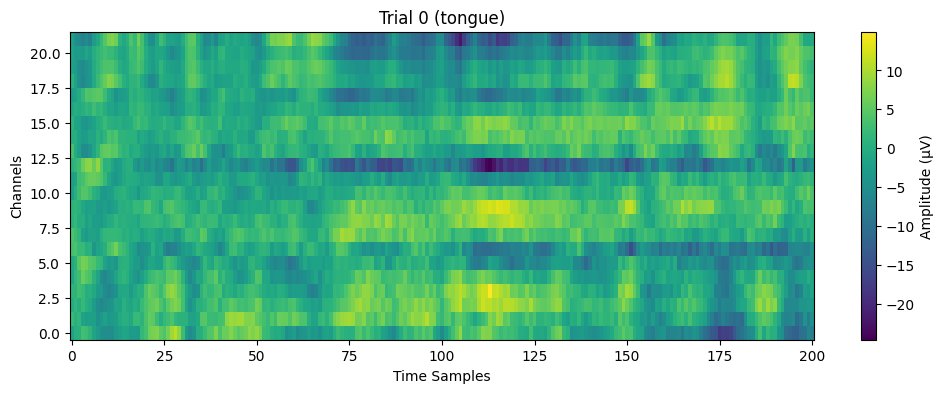

In [17]:
trial = 0

plt.imshow(
    X[trial],
    aspect="auto",
    origin="lower"
)

plt.xlabel("Time Samples")
plt.ylabel("Channels")
plt.title(f"Trial {trial} ({y[trial]})")
plt.colorbar(label="Amplitude (µV)")
plt.show()

In [18]:
print("Trials   :", X.shape[0])
print("Channels :", X.shape[1])
print("Samples  :", X.shape[2])

print()

print("First trial label:")
print(y[0])

print()

print("First channel (first 10 samples):")
print(X[0, 0, :10])

Trials   : 288
Channels : 22
Samples  : 201

First trial label:
tongue

First channel (first 10 samples):
[-1.68141185  0.42041699  0.55136514  3.05491628  2.5067096   1.1506194
 -1.53714694 -2.97979608 -4.7420475  -5.06164978]


In [19]:
eeg_columns = [col for col in df.columns if col.startswith("EEG")]
channel_to_idx = {
    ch: i
    for i, ch in enumerate(eeg_columns)
}

channel_to_idx

{'EEG-Fz': 0,
 'EEG-0': 1,
 'EEG-1': 2,
 'EEG-2': 3,
 'EEG-3': 4,
 'EEG-4': 5,
 'EEG-5': 6,
 'EEG-C3': 7,
 'EEG-6': 8,
 'EEG-Cz': 9,
 'EEG-7': 10,
 'EEG-C4': 11,
 'EEG-8': 12,
 'EEG-9': 13,
 'EEG-10': 14,
 'EEG-11': 15,
 'EEG-12': 16,
 'EEG-13': 17,
 'EEG-14': 18,
 'EEG-Pz': 19,
 'EEG-15': 20,
 'EEG-16': 21}

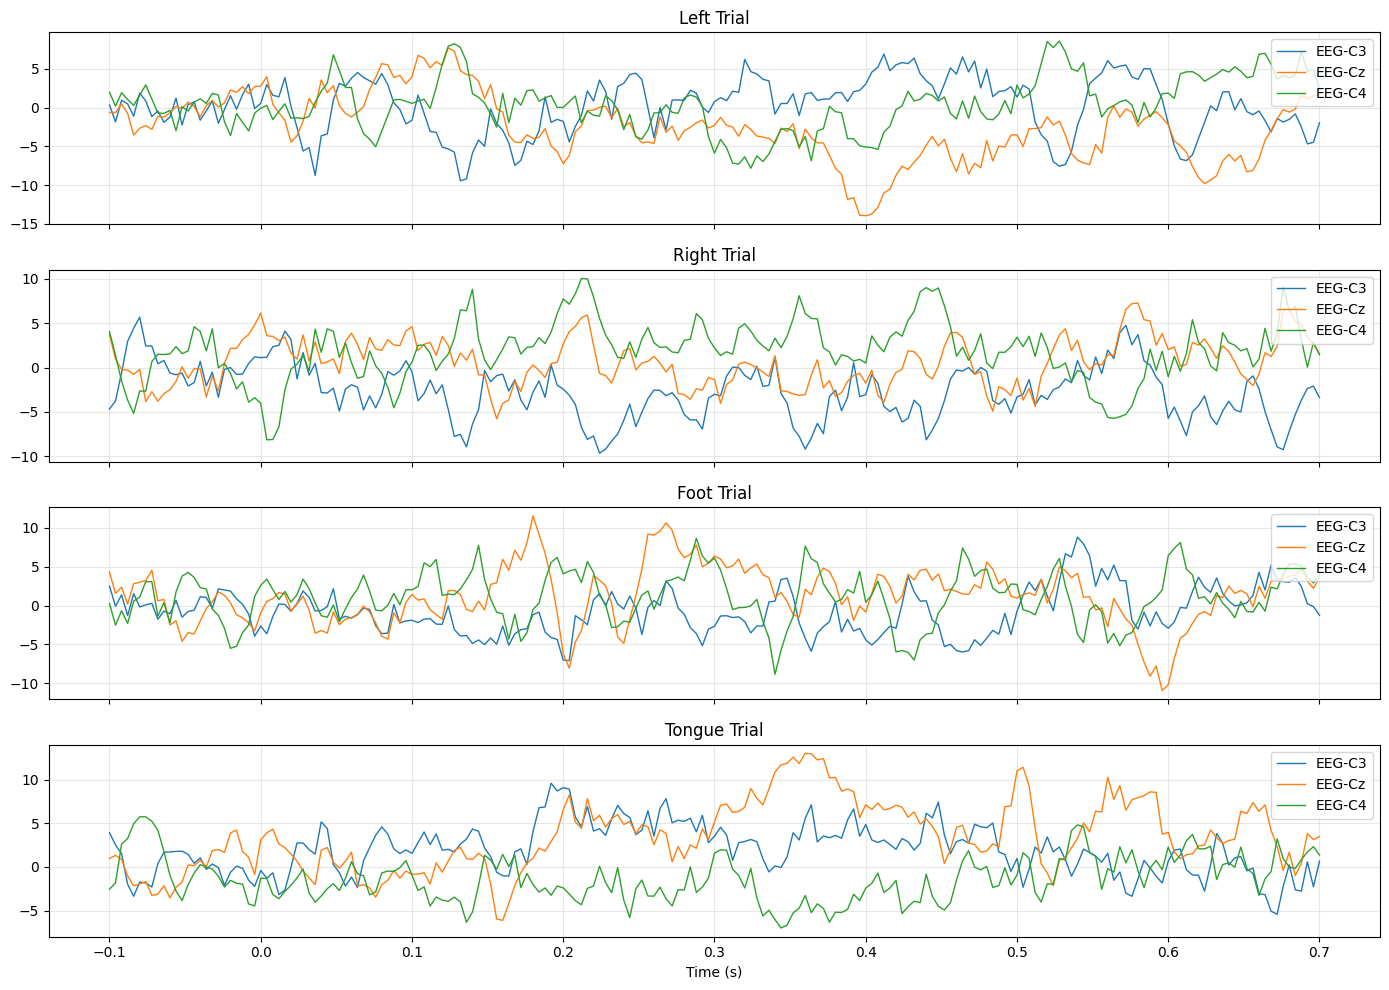

In [20]:
time = np.linspace(-0.1, 0.7, X.shape[2])
motor_channels = ["EEG-C3", "EEG-Cz", "EEG-C4"]
classes = ["left", "right", "foot", "tongue"]
fig, axes = plt.subplots(len(classes), 1, figsize=(14, 10), sharex=True)

for ax, label in zip(axes, classes):
    trial_idx = np.where(y == label)[0][0]
    for ch in motor_channels:
        idx = channel_to_idx[ch]
        ax.plot(
            time,
            X[trial_idx, idx],
            label=ch,
            linewidth=1
        )
    ax.set_title(f"{label.capitalize()} Trial")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

# 2. Preprocessing Phase

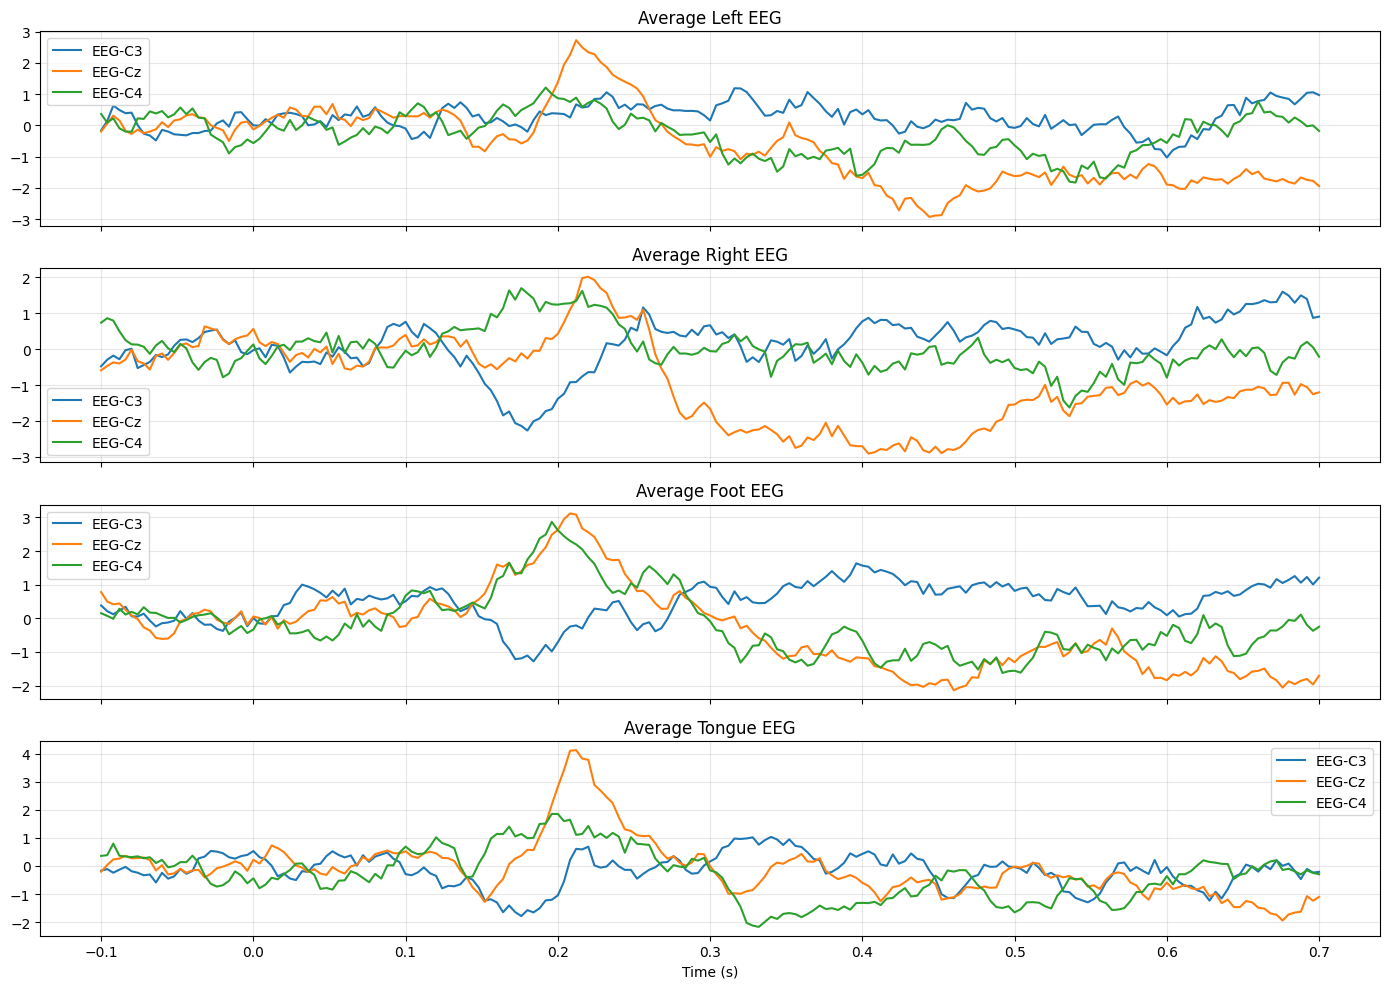

In [21]:
fig, axes = plt.subplots(len(classes), 1, figsize=(14, 10), sharex=True)

for ax, label in zip(axes, classes):
    class_trials = X[y == label]
    mean_trial = class_trials.mean(axis=0)

    for ch in motor_channels:
        idx = channel_to_idx[ch]
        ax.plot(
            time,
            mean_trial[idx],
            label=ch
        )

    ax.set_title(f"Average {label.capitalize()} EEG")
    ax.legend()
    ax.grid(alpha=0.3)

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()

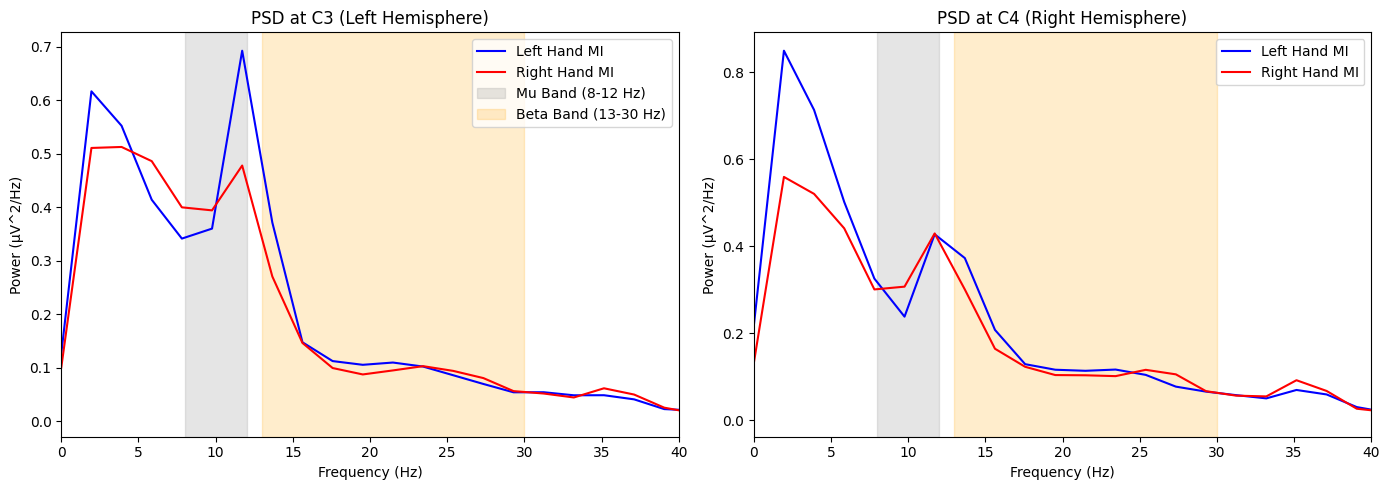

In [22]:
from scipy import signal

# The BCI Comp IV 2a dataset is sampled at 250 Hz
fs = 250  

c3_idx = channel_to_idx["EEG-C3"]
c4_idx = channel_to_idx["EEG-C4"]

# Separate trials for Left and Right hand motor imagery
left_trials = X[y == 'left']
right_trials = X[y == 'right']

# Compute Power Spectral Density (PSD) using Welch's method
freqs, psd_left_c3 = signal.welch(left_trials[:, c3_idx, :], fs=fs, nperseg=128, axis=-1)
freqs, psd_left_c4 = signal.welch(left_trials[:, c4_idx, :], fs=fs, nperseg=128, axis=-1)

freqs, psd_right_c3 = signal.welch(right_trials[:, c3_idx, :], fs=fs, nperseg=128, axis=-1)
freqs, psd_right_c4 = signal.welch(right_trials[:, c4_idx, :], fs=fs, nperseg=128, axis=-1)

# Average across all trials
mean_psd_left_c3 = np.mean(psd_left_c3, axis=0)
mean_psd_left_c4 = np.mean(psd_left_c4, axis=0)
mean_psd_right_c3 = np.mean(psd_right_c3, axis=0)
mean_psd_right_c4 = np.mean(psd_right_c4, axis=0)

# Plotting the PSD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot C3 (Left Hemisphere)
ax1.plot(freqs, mean_psd_left_c3, label='Left Hand MI', color='blue')
ax1.plot(freqs, mean_psd_right_c3, label='Right Hand MI', color='red')
ax1.set_title('PSD at C3 (Left Hemisphere)')
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('Power (µV^2/Hz)')
ax1.set_xlim(0, 40)
ax1.axvspan(8, 12, color='gray', alpha=0.2, label='Mu Band (8-12 Hz)')
ax1.axvspan(13, 30, color='orange', alpha=0.2, label='Beta Band (13-30 Hz)')
ax1.legend()

# Plot C4 (Right Hemisphere)
ax2.plot(freqs, mean_psd_left_c4, label='Left Hand MI', color='blue')
ax2.plot(freqs, mean_psd_right_c4, label='Right Hand MI', color='red')
ax2.set_title('PSD at C4 (Right Hemisphere)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Power (µV^2/Hz)')
ax2.set_xlim(0, 40)
ax2.axvspan(8, 12, color='gray', alpha=0.2)
ax2.axvspan(13, 30, color='orange', alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

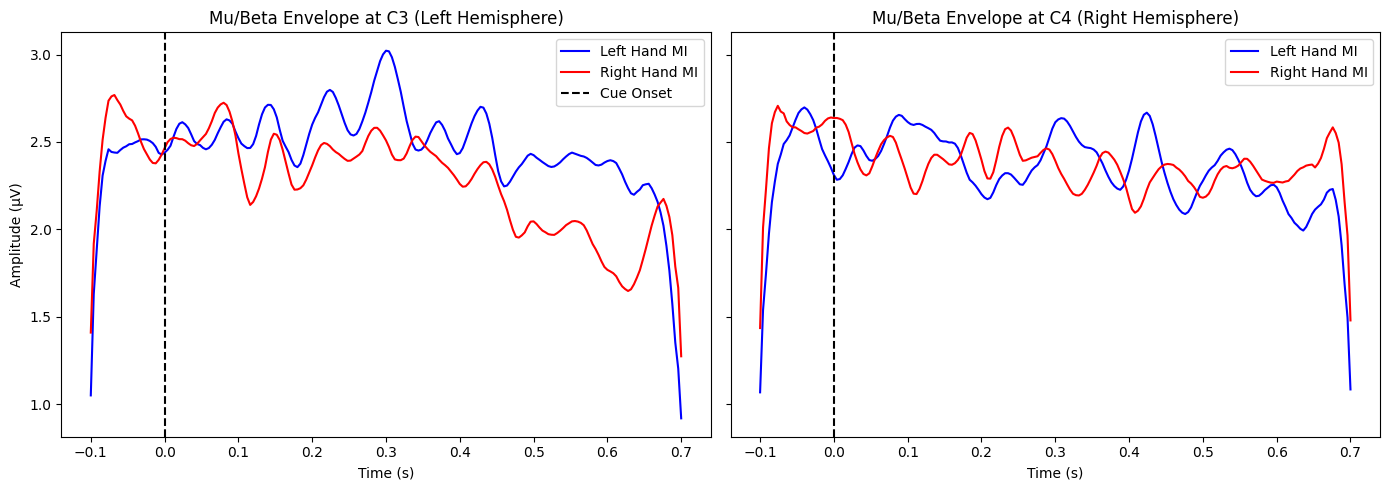

In [23]:
# Create a Bandpass filter for the Mu and Beta bands (8 - 30 Hz)
b, a = signal.butter(4, [8, 30], btype='bandpass', fs=fs)

# Function to extract the envelope of the filtered signal
def get_band_envelope(trials):
    # Filter the signals
    filtered = signal.filtfilt(b, a, trials, axis=-1)
    # Apply Hilbert transform to get the analytical signal
    analytic_signal = signal.hilbert(filtered, axis=-1)
    # The amplitude envelope is the magnitude of the analytical signal
    amplitude_envelope = np.abs(analytic_signal)
    return amplitude_envelope

# Get envelopes for left and right trials
env_left = get_band_envelope(left_trials)
env_right = get_band_envelope(right_trials)

# Average across trials
mean_env_left = np.mean(env_left, axis=0)
mean_env_right = np.mean(env_right, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot C3 Amplitude Envelope over time
ax1.plot(time, mean_env_left[c3_idx], label='Left Hand MI', color='blue')
ax1.plot(time, mean_env_right[c3_idx], label='Right Hand MI', color='red')
ax1.set_title('Mu/Beta Envelope at C3 (Left Hemisphere)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (µV)')
ax1.axvline(x=0, color='black', linestyle='--', label='Cue Onset')
ax1.legend()

# Plot C4 Amplitude Envelope over time
ax2.plot(time, mean_env_left[c4_idx], label='Left Hand MI', color='blue')
ax2.plot(time, mean_env_right[c4_idx], label='Right Hand MI', color='red')
ax2.set_title('Mu/Beta Envelope at C4 (Right Hemisphere)')
ax2.set_xlabel('Time (s)')
ax2.axvline(x=0, color='black', linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()

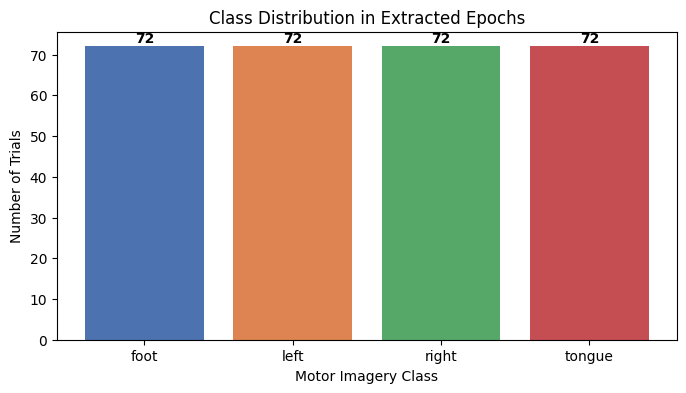

In [24]:
# Check final label distribution across the entirely loaded dataset
unique_labels, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(unique_labels, counts, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.title('Class Distribution in Extracted Epochs')
plt.xlabel('Motor Imagery Class')
plt.ylabel('Number of Trials')

for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', fontweight='bold')

plt.show()

### Missing Preprocessing Steps: Baseline Correction & Artifact Rejection

Two standard EEG-preprocessing steps that were absent and lower accuracy when omitted:

| Step | Implementation | Effect on CSP |
|------|---------------|---------------|
| **Baseline correction** | Subtract the per-channel mean of the pre-cue period (−0.1 → 0 s, 25 samples) | Removes slow drifts/DC offsets that inflate off-diagonal covariance entries |
| **Artifact rejection** | Discard epochs whose peak-to-peak amplitude exceeds 100 µV | Prevents outlier trials from corrupting covariance matrix estimates |

Additionally: the previous Section 3 trained **on a single random split of Patient 1 only** (230 training samples across 4 classes). EEG subjects vary enormously, the correct evaluation strategy is **per-subject training with stratified k-fold CV**.

In [25]:
PRE_CUE_SAMPLES = 25   # -0.1 to 0.0 s at 250 Hz

def baseline_correct(X, pre_cue=PRE_CUE_SAMPLES):
    baseline = X[:, :, :pre_cue].mean(axis=2, keepdims=True)
    return X - baseline

def detect_artifacts(X, threshold=100.0):
    peak_to_peak = X.max(axis=2) - X.min(axis=2)  # (N, C)
    return peak_to_peak.max(axis=1) < threshold    # (N,)  True = clean

print(f"{'Patient':>8}  {'Trials':>6}  {'Rejected':>8}  {'Max p-p (µV)':>13}")
print("-" * 44)
for csv_path in patient_files:
    X_p, _ = load_patient(csv_path)
    pid     = int(csv_path.stem.split("_")[-1])
    clean   = detect_artifacts(X_p)
    pp_max  = (X_p.max(axis=2) - X_p.min(axis=2)).max(axis=1).max()
    print(f"{pid:>8}  {len(X_p):>6}  {(~clean).sum():>8}  {pp_max:>13.1f}")


 Patient  Trials  Rejected   Max p-p (µV)
--------------------------------------------
       1     288         0           60.9
       2     288         1          106.0
       3     288         0           54.2
       4     144         2          113.4
       5     288         0           59.8
       6     288         1          114.3
       7     288         0           87.7
       8     288         0           94.6
       9     288         2          119.0


# 3. Feature Extraction & Classical ML Classification

## Why the Previous 33 % Accuracy Was Near-Chance

| Issue | Fix applied below |
|-------|------------------|
| Single-patient, random-split training | **Per-subject 5-fold stratified CV** |
| `n_components=4` (too few) | Increased to **6** spatial filters |
| No baseline correction | Bandpass + baseline in `preprocess_csp()` |
| No regularisation on covariance | `reg='oas'` (Oracle Approximating Shrinkage) |
| Only LDA | Added **SVM (RBF)** and **Voting Ensemble** |
| Only accuracy reported | Added **Cohen's κ** (official BCI Competition IV metric) |

**Note on window length**: the data covers −0.1 → 0.7 s after cue onset. Motor-imagery ERD
typically peaks 0.5–2 s post-cue. This 0.8 s window is an inherent limitation of the provided
dataset; typical BCI2a analysis uses a 2–4 s window and achieves 60–80 % per subject. With this
short window, 40–60 % per subject is a realistic ceiling for classical methods.

In [26]:
import mne
mne.set_log_level('WARNING')

from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
from mne.decoding import CSP
from mne.filter import filter_data
import time

N_COMP  = 6   # spatial filters for OVR-CSP
N_FOLDS = 5   # stratified k-fold per subject

# ── Shared preprocessing for CSP ─────────────────────────────────────────────
def preprocess_csp(X, fs=250, l_freq=8.0, h_freq=30.0, pre_cue=PRE_CUE_SAMPLES):
    Xf  = filter_data(X.astype(np.float64), sfreq=fs, l_freq=l_freq,
                      h_freq=h_freq, method='iir', verbose=False).astype(np.float32)
    Xf -= Xf[:, :, :pre_cue].mean(axis=2, keepdims=True)   # baseline correct
    return Xf

# ── Load all 9 patients ───────────────────────────────────────────────────────
def load_all_csp():
    all_X, all_y, all_pid = [], [], []
    for csv_path in sorted(DATA_DIR.glob("*.csv")):
        Xp, yp  = load_patient(csv_path)
        pid     = int(csv_path.stem.split("_")[-1])
        all_X.append(Xp); all_y.append(yp)
        all_pid.extend([pid] * len(Xp))
    return np.concatenate(all_X), np.concatenate(all_y), np.array(all_pid)

print("Loading all 9 patients…")
X_raw_csp, y_raw_csp, pid_csp = load_all_csp()

print("Bandpass 8–30 Hz + baseline correction…")
X_csp = preprocess_csp(X_raw_csp)

le_csp  = LabelEncoder()
y_csp   = le_csp.fit_transform(y_raw_csp)

# Artifact rejection
clean        = detect_artifacts(X_csp)
n_rejected   = (~clean).sum()
X_csp, y_csp, pid_csp = X_csp[clean], y_csp[clean], pid_csp[clean]
print(f"Dataset: {X_csp.shape}  |  rejected: {n_rejected}")
print(f"Classes: {dict(enumerate(le_csp.classes_))}")


Loading all 9 patients…
Bandpass 8–30 Hz + baseline correction…
Dataset: (2448, 22, 201)  |  rejected: 0
Classes: {0: 'foot', 1: 'left', 2: 'right', 3: 'tongue'}


## 3.1 Per-Subject Evaluation Utility

`per_subject_cv` runs stratified k-fold within **each patient separately**, which is the correct
evaluation protocol for BCI2a (each subject has their own calibration session).

In [27]:
def per_subject_cv(make_pipe, name, n_folds=N_FOLDS):
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    rows = []
    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"  {'Patient':>8}  {'Acc':>6}  {'±':>5}  {'κ':>6}  {'±':>5}")
    print(f"  {'─'*44}")
    for pid in sorted(np.unique(pid_csp)):
        mask    = pid_csp == pid
        Xp, yp  = X_csp[mask], y_csp[mask]
        accs, ks = [], []
        for tr, te in skf.split(Xp, yp):
            pipe = make_pipe()
            pipe.fit(Xp[tr], yp[tr])
            yh   = pipe.predict(Xp[te])
            accs.append(accuracy_score(yp[te], yh))
            ks.append(cohen_kappa_score(yp[te], yh))
        rows.append(dict(patient=pid,
                         acc=np.mean(accs), acc_std=np.std(accs),
                         kappa=np.mean(ks),  kappa_std=np.std(ks)))
        print(f"  {pid:>8}  {np.mean(accs):>6.3f}  {np.std(accs):>5.3f}  "
              f"{np.mean(ks):>6.3f}  {np.std(ks):>5.3f}")
    ma = np.mean([r['acc']   for r in rows])
    mk = np.mean([r['kappa'] for r in rows])
    print(f"  {'─'*44}")
    print(f"  {'Mean':>8}  {ma:>6.3f}              {mk:>6.3f}")
    return rows


## 3.2 CSP + LDA

Gold-standard BCI2a pipeline: One-vs-Rest CSP (OAS covariance) → log-variance features → LDA.

In [28]:
def make_lda():
    return Pipeline([
        ('csp', CSP(n_components=N_COMP, reg='oas', log=True, norm_trace=False)),
        ('lda', LDA()),
    ])

t0 = time.time()
res_lda = per_subject_cv(make_lda, f"CSP (n={N_COMP}, reg=OAS) + LDA")
print(f"  Elapsed {time.time()-t0:.1f} s")



────────────────────────────────────────────────────
  CSP (n=6, reg=OAS) + LDA
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.343  0.074   0.124  0.098
         2   0.326  0.086   0.102  0.115
         3   0.336  0.055   0.115  0.074
         4   0.535  0.042   0.070  0.085
         5   0.309  0.038   0.080  0.052
         6   0.340  0.050   0.121  0.069
         7   0.343  0.064   0.125  0.086
         8   0.333  0.020   0.111  0.026
         9   0.413  0.052   0.217  0.069
  ────────────────────────────────────────────
      Mean   0.364               0.118
  Elapsed 19.7 s


## 3.3 CSP + SVM (RBF kernel)

SVM with RBF kernel is typically the strongest single classifier on CSP features in BCI2a.

In [29]:
def make_svm():
    return Pipeline([
        ('csp', CSP(n_components=N_COMP, reg='oas', log=True, norm_trace=False)),
        ('svm', SVC(kernel='rbf', C=10.0, gamma='scale',
                    probability=True, random_state=42)),
    ])

t0 = time.time()
res_svm = per_subject_cv(make_svm, f"CSP (n={N_COMP}, reg=OAS) + SVM (RBF, C=10)")
print(f"  Elapsed {time.time()-t0:.1f} s")



────────────────────────────────────────────────────
  CSP (n=6, reg=OAS) + SVM (RBF, C=10)
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.354  0.079   0.139  0.106
         2   0.274  0.080   0.032  0.107
         3   0.344  0.052   0.125  0.069
         4   0.569  0.056   0.138  0.111
         5   0.337  0.016   0.116  0.021
         6   0.302  0.102   0.070  0.135
         7   0.298  0.065   0.064  0.087
         8   0.302  0.069   0.069  0.093
         9   0.417  0.037   0.222  0.049
  ────────────────────────────────────────────
      Mean   0.355               0.108
  Elapsed 21.1 s


## 3.4 Voting Ensemble (LDA + SVM + RF)

Soft-vote over LDA, SVM, and Random Forest, all operating on the same CSP features.
Diversity comes from the classifiers, not the features.

In [30]:
def make_ensemble():
    return Pipeline([
        ('csp', CSP(n_components=N_COMP, reg='oas', log=True, norm_trace=False)),
        ('vote', VotingClassifier(
            estimators=[
                ('lda', LDA()),
                ('svm', SVC(kernel='rbf', C=10.0, gamma='scale',
                            probability=True, random_state=42)),
                ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
            ],
            voting='soft',
        )),
    ])

t0 = time.time()
res_ens = per_subject_cv(make_ensemble, "Voting Ensemble (LDA + SVM + RF)")
print(f"  Elapsed {time.time()-t0:.1f} s")



────────────────────────────────────────────────────
  Voting Ensemble (LDA + SVM + RF)
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.371  0.080   0.161  0.107
         2   0.330  0.070   0.106  0.094
         3   0.354  0.062   0.138  0.083
         4   0.556  0.065   0.112  0.129
         5   0.312  0.035   0.084  0.047
         6   0.361  0.071   0.149  0.096
         7   0.354  0.071   0.139  0.094
         8   0.330  0.045   0.106  0.059
         9   0.420  0.058   0.226  0.077
  ────────────────────────────────────────────
      Mean   0.376               0.136
  Elapsed 26.1 s


## 3.5 Results Summary

In [31]:
summary = pd.DataFrame({
    'Patient':   [r['patient']  for r in res_lda],
    'LDA acc':   [r['acc']      for r in res_lda],
    'LDA κ':     [r['kappa']    for r in res_lda],
    'SVM acc':   [r['acc']      for r in res_svm],
    'SVM κ':     [r['kappa']    for r in res_svm],
    'Ens acc':   [r['acc']      for r in res_ens],
    'Ens κ':     [r['kappa']    for r in res_ens],
})
mean_row        = summary.drop(columns='Patient').mean().to_dict()
mean_row['Patient'] = 'Mean'
summary = pd.concat([summary, pd.DataFrame([mean_row])], ignore_index=True)
print(summary.set_index('Patient').round(3).to_string())


         LDA acc  LDA κ  SVM acc  SVM κ  Ens acc  Ens κ
Patient                                                
1          0.343  0.124    0.354  0.139    0.371  0.161
2          0.326  0.102    0.274  0.032    0.330  0.106
3          0.336  0.115    0.344  0.125    0.354  0.138
4          0.535  0.070    0.569  0.138    0.556  0.112
5          0.309  0.080    0.337  0.116    0.312  0.084
6          0.340  0.121    0.302  0.070    0.361  0.149
7          0.343  0.125    0.298  0.064    0.354  0.139
8          0.333  0.111    0.302  0.069    0.330  0.106
9          0.413  0.217    0.417  0.222    0.420  0.226
Mean       0.364  0.118    0.355  0.108    0.376  0.136


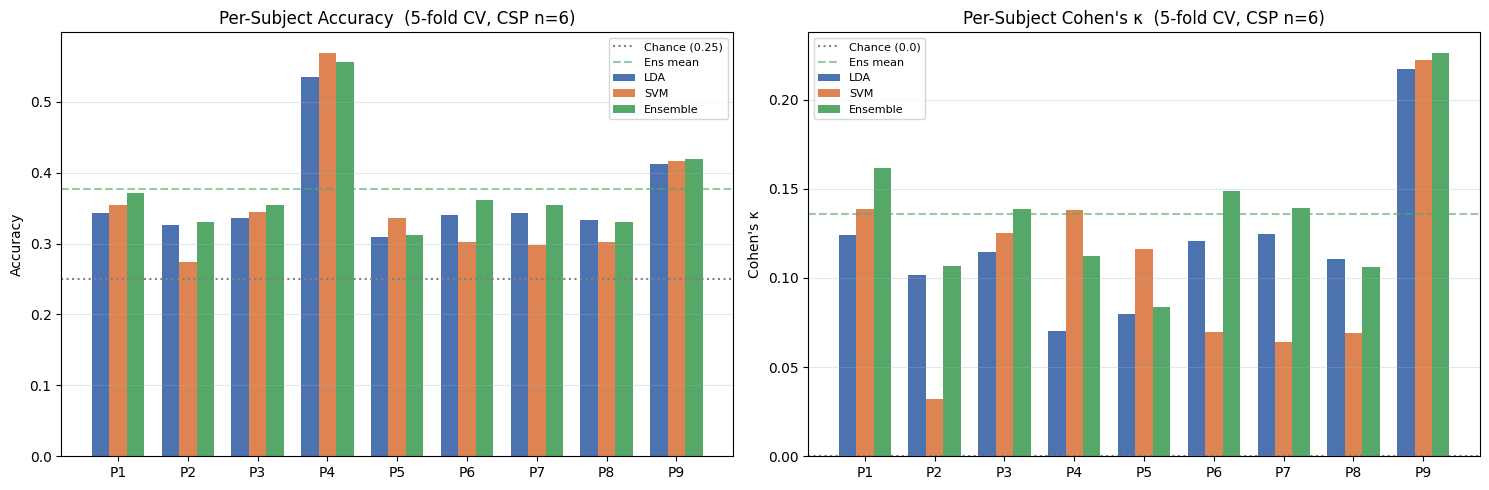

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
pts = [r['patient'] for r in res_lda]
x   = np.arange(len(pts))
w   = 0.25

for ax, metric, ylabel in zip(
        axes,
        [('acc', 0.25, 'Accuracy'), ('kappa', 0.0, "Cohen's κ")],
        ['Accuracy', "Cohen's κ"]):
    key, chance, title_suffix = metric
    ax.bar(x - w, [r[key] for r in res_lda], w, label='LDA',      color='#4C72B0')
    ax.bar(x,     [r[key] for r in res_svm], w, label='SVM',      color='#DD8452')
    ax.bar(x + w, [r[key] for r in res_ens], w, label='Ensemble', color='#55A868')
    ax.axhline(chance, color='gray', linestyle=':', label=f'Chance ({chance})')
    ax.axhline(np.mean([r[key] for r in res_ens]), color='#55A868',
               linestyle='--', alpha=0.6, label='Ens mean')
    ax.set_xticks(x)
    ax.set_xticklabels([f'P{p}' for p in pts])
    ax.set_ylabel(ylabel)
    ax.set_title(f'Per-Subject {ylabel}  (5-fold CV, CSP n={N_COMP})')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 3.6 Cross-Subject Baseline (LOSO: CSP + LDA)

Train on 8 subjects, test on the held-out 9th, identical protocol to EEGNet in Section 4.
This reveals how much accuracy degrades when generalising across subjects, and sets the
baseline that EEGNet aims to beat.

In [33]:
logo     = LeaveOneGroupOut()
loso_res = []

print("CSP + LDA: LOSO cross-subject")
print(f"{'Patient':>8}  {'Acc':>6}  {'κ':>6}")
print("-" * 26)

for tr, te in logo.split(X_csp, y_csp, pid_csp):
    pipe = make_lda()
    pipe.fit(X_csp[tr], y_csp[tr])
    yh   = pipe.predict(X_csp[te])
    pid  = pid_csp[te[0]]
    acc  = accuracy_score(y_csp[te], yh)
    k    = cohen_kappa_score(y_csp[te], yh)
    loso_res.append(dict(patient=pid, acc=acc, kappa=k))
    print(f"{pid:>8}  {acc:>6.3f}  {k:>6.3f}")

la = np.mean([r['acc']   for r in loso_res])
lk = np.mean([r['kappa'] for r in loso_res])
print("-" * 26)
print(f"{'Mean':>8}  {la:>6.3f}  {lk:>6.3f}")
print()
print("Per-subject mean (Ensemble) :", round(np.mean([r['acc'] for r in res_ens]), 3))
print("Cross-subject (LOSO CSP+LDA):", round(la, 3))
print("→ EEGNet LOSO target is Section 4.")


CSP + LDA: LOSO cross-subject
 Patient     Acc       κ
--------------------------
       1   0.337   0.116
       2   0.330   0.106
       3   0.285   0.046
       4   0.549   0.103
       5   0.260   0.014
       6   0.309   0.079
       7   0.295   0.060
       8   0.344   0.125
       9   0.361   0.148
--------------------------
    Mean   0.341   0.089

Per-subject mean (Ensemble) : 0.376
Cross-subject (LOSO CSP+LDA): 0.341
→ EEGNet LOSO target is Section 4.


# 4. EEGNet: Deep Learning Model

EEGNet (Lawhern et al., 2018) is a compact CNN designed for EEG-based BCI. It uses depthwise and separable convolutions to learn temporal and spatial filters from raw data.

**Training strategy**: Leave-One-Subject-Out (LOSO) cross-validation, train on 8 patients, evaluate on the held-out 9th, repeat for all 9 patients. A final model is then trained on all 9 patients for deployment.

In [34]:
import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [35]:
def load_all_patients(data_dir):
    """Load all 9 patients into a single array with patient ID labels."""
    all_X, all_y, all_patients = [], [], []
    for csv_path in sorted(Path(data_dir).glob("*.csv")):
        X_p, y_p = load_patient(csv_path)
        patient_id = int(csv_path.stem.split("_")[-1])
        all_X.append(X_p)
        all_y.append(y_p)
        all_patients.extend([patient_id] * len(X_p))
    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)
    patients = np.array(all_patients)
    return X, y, patients

X_all, y_all, patient_ids = load_all_patients(DATA_DIR)
print(f"Shape  : {X_all.shape}, (trials, channels, samples)")
print(f"Labels : {y_all.shape}")
print(f"Patients: {np.unique(patient_ids)}")
print(f"Class distribution: {dict(zip(*np.unique(y_all, return_counts=True)))}")


Shape  : (2448, 22, 201), (trials, channels, samples)
Labels : (2448,)
Patients: [1 2 3 4 5 6 7 8 9]
Class distribution: {'foot': 576, 'left': 648, 'right': 648, 'tongue': 576}


In [36]:
from mne.filter import filter_data

def bandpass_filter(X, fs=250, l_freq=4.0, h_freq=38.0):
    """Zero-phase IIR bandpass filter covering mu (8-12 Hz) and beta (13-30 Hz) bands."""
    return filter_data(
        X.astype(np.float64), sfreq=fs,
        l_freq=l_freq, h_freq=h_freq,
        method='iir', verbose=False,
    ).astype(np.float32)

def normalize_epochs(X):
    """Per-trial, per-channel z-score normalisation across the time axis."""
    mean = X.mean(axis=2, keepdims=True)   # (N, C, 1)
    std  = X.std(axis=2, keepdims=True)
    return (X - mean) / (std + 1e-8)

print("Applying bandpass filter (4–38 Hz)…")
X_proc = bandpass_filter(X_all)
print("Normalising epochs (per-channel z-score)…")
X_proc = normalize_epochs(X_proc)
print(f"Processed: {X_proc.shape}  dtype={X_proc.dtype}")


Applying bandpass filter (4–38 Hz)…
Normalising epochs (per-channel z-score)…
Processed: (2448, 22, 201)  dtype=float32


In [37]:
le = LabelEncoder()
y_enc = le.fit_transform(y_all)
print(f"Classes (encoded): {dict(enumerate(le.classes_))}")


Classes (encoded): {0: 'foot', 1: 'left', 2: 'right', 3: 'tongue'}


In [38]:
class EEGNet(nn.Module):
    """
    EEGNet: Lawhern et al. (2018).

    Architecture
    ------------
    Block 1  : Temporal Conv → Depthwise Spatial Conv → ELU → AvgPool → Dropout
    Block 2  : Depthwise Temporal Conv → Pointwise Conv → ELU → AvgPool → Dropout
    Classifier: Linear
    """

    def __init__(
        self,
        n_classes: int = 4,
        n_channels: int = 22,
        n_samples: int = 201,
        F1: int = 8,
        D: int = 2,
        kernel_length: int = 64,
        dropout_rate: float = 0.5,
    ):
        super().__init__()
        F2 = F1 * D

        # Block 1
        self.block1 = nn.Sequential(
            # Temporal convolution
            nn.Conv2d(1, F1, (1, kernel_length),
                      padding=(0, kernel_length // 2), bias=False),
            nn.BatchNorm2d(F1),
            # Depthwise spatial filter (one per temporal filter)
            nn.Conv2d(F1, F2, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout_rate),
        )

        # Block 2: separable convolution
        self.block2 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout_rate),
        )

        # Dynamically compute the flattened feature size
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            out   = self.block2(self.block1(dummy))
            self._flat_size = out.numel()

        self.classifier = nn.Linear(self._flat_size, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3:           # (B, C, T) → (B, 1, C, T)
            x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x.flatten(1))


# Sanity-check
_m   = EEGNet()
_out = _m(torch.randn(4, 22, 201))
params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Output shape    : {_out.shape}")
print(f"Flatten size    : {_m._flat_size}")
print(f"Trainable params: {params:,}")
del _m, _out


Output shape    : torch.Size([4, 4])
Flatten size    : 96
Trainable params: 1,844


In [39]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = correct = total = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model(Xb)
        loss   = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds, probs = [], []
    for Xb, _ in loader:
        Xb    = Xb.to(device)
        logits = model(Xb)
        probs.append(torch.softmax(logits, 1).cpu().numpy())
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds), np.concatenate(probs)


## 4.1 LOSO Cross-Validation

Leave-One-Subject-Out: for each fold, one patient is withheld as the test set and the model is trained from scratch on the remaining 8. A 10 % slice of the training patients is used as a validation set for early stopping (no information from the test patient leaks in).

In [40]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
N_EPOCHS     = 300
BATCH_SIZE   = 64
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 40    # epochs without val-loss improvement before early stop

logo = LeaveOneGroupOut()
fold_results = []

for fold, (train_idx, test_idx) in enumerate(
        logo.split(X_proc, y_enc, patient_ids)):

    test_patient = patient_ids[test_idx[0]]
    print(f"\n─── Fold {fold+1}/9 │ test patient: {test_patient} ───")

    # 10 % of *training* patients as validation (early-stop only)
    tr_idx, val_idx = train_test_split(
        train_idx, test_size=0.1, random_state=42,
        stratify=y_enc[train_idx],
    )

    def make_loader(idx, shuffle=False):
        return DataLoader(
            TensorDataset(
                torch.FloatTensor(X_proc[idx]),
                torch.LongTensor(y_enc[idx]),
            ),
            batch_size=BATCH_SIZE, shuffle=shuffle, pin_memory=True,
        )

    train_loader = make_loader(tr_idx,    shuffle=True)
    val_loader   = make_loader(val_idx)
    test_loader  = make_loader(test_idx)

    model     = EEGNet(n_classes=4, n_channels=22, n_samples=201).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=15, factor=0.5, min_lr=1e-5,
    )
    criterion = nn.CrossEntropyLoss()

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0
    best_epoch     = 0

    for epoch in range(N_EPOCHS):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = eval_epoch(model, val_loader,   criterion, device)
        scheduler.step(va_loss)

        if va_loss < best_val_loss:
            best_val_loss  = va_loss
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            best_epoch     = epoch
        else:
            patience_count += 1

        if (epoch + 1) % 50 == 0:
            print(f"  ep {epoch+1:3d} │ tr {tr_loss:.4f}/{tr_acc:.3f}"
                  f"  val {va_loss:.4f}/{va_acc:.3f}")

        if patience_count >= PATIENCE:
            print(f"  Early stop at epoch {epoch+1}  (best: {best_epoch+1})")
            break

    model.load_state_dict(best_state)
    y_pred, y_prob = predict(model, test_loader, device)
    acc = accuracy_score(y_enc[test_idx], y_pred)
    fold_results.append({
        'patient': test_patient,
        'accuracy': acc,
        'y_true':   y_enc[test_idx],
        'y_pred':   y_pred,
        'y_prob':   y_prob,
    })
    print(f"  ✓ Test accuracy: {acc:.4f}")

# ── Summary ───────────────────────────────────────────────────────────────────
accs = [r['accuracy'] for r in fold_results]
print(f"\n{'='*45}")
print(f"LOSO mean accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"{'='*45}")
for r in fold_results:
    print(f"  Patient {r['patient']:>2d}: {r['accuracy']:.4f}")



─── Fold 1/9 │ test patient: 1 ───
  ep  50 │ tr 1.2042/0.462  val 1.2304/0.435
  ep 100 │ tr 1.1432/0.492  val 1.1901/0.468
  Early stop at epoch 124  (best: 84)
  ✓ Test accuracy: 0.4410

─── Fold 2/9 │ test patient: 2 ───
  ep  50 │ tr 1.2096/0.474  val 1.2289/0.380
  ep 100 │ tr 1.1547/0.496  val 1.2089/0.389
  ep 150 │ tr 1.1473/0.498  val 1.2000/0.431
  Early stop at epoch 180  (best: 140)
  ✓ Test accuracy: 0.3368

─── Fold 3/9 │ test patient: 3 ───
  ep  50 │ tr 1.2155/0.450  val 1.2600/0.384
  Early stop at epoch 75  (best: 35)
  ✓ Test accuracy: 0.3542

─── Fold 4/9 │ test patient: 4 ───
  ep  50 │ tr 1.1906/0.458  val 1.2414/0.424
  ep 100 │ tr 1.1395/0.495  val 1.1972/0.446
  ep 150 │ tr 1.0969/0.527  val 1.1586/0.481
  ep 200 │ tr 1.0810/0.541  val 1.1416/0.515
  ep 250 │ tr 1.0699/0.532  val 1.1382/0.515
  Early stop at epoch 252  (best: 212)
  ✓ Test accuracy: 0.2153

─── Fold 5/9 │ test patient: 5 ───
  ep  50 │ tr 1.1813/0.479  val 1.2331/0.440
  Early stop at epoch 7

## 4.2 Results

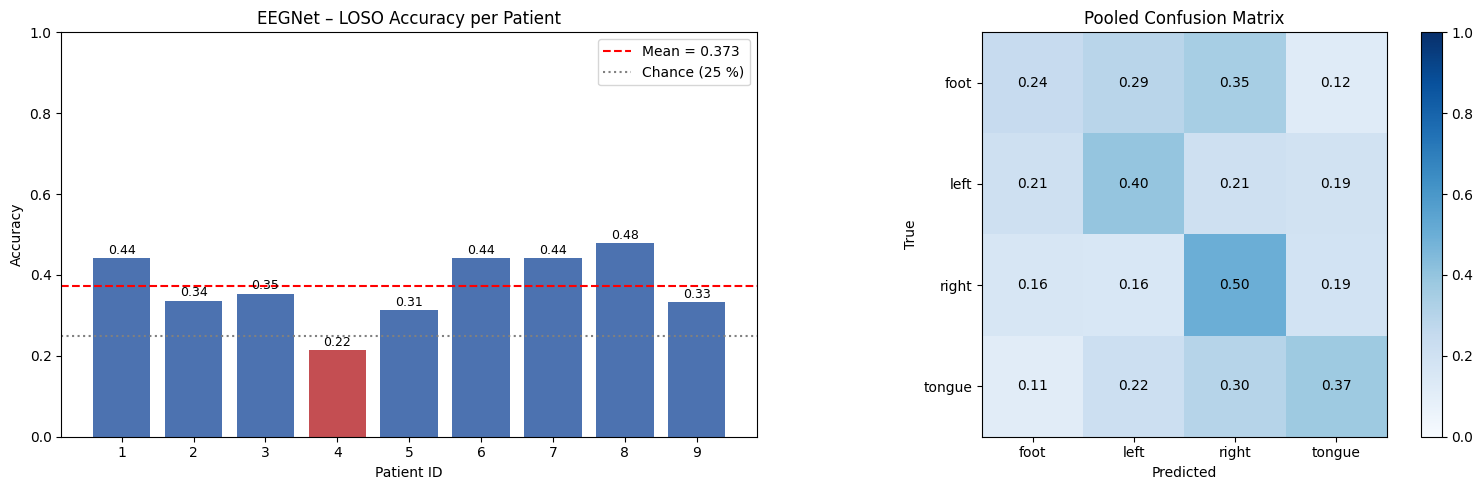


Pooled classification report:
              precision    recall  f1-score   support

        foot       0.32      0.24      0.28       576
        left       0.40      0.40      0.40       648
       right       0.39      0.50      0.44       648
      tongue       0.41      0.37      0.39       576

    accuracy                           0.38      2448
   macro avg       0.38      0.38      0.37      2448
weighted avg       0.38      0.38      0.38      2448



In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Per-patient accuracy ──────────────────────────────────────────────────────
ax = axes[0]
pts   = [r['patient']  for r in fold_results]
accs_ = [r['accuracy'] for r in fold_results]
colors = ['#4C72B0' if a > 0.25 else '#C44E52' for a in accs_]
bars = ax.bar(pts, accs_, color=colors)
ax.axhline(np.mean(accs_), color='red', linestyle='--',
           label=f'Mean = {np.mean(accs_):.3f}')
ax.axhline(0.25, color='gray', linestyle=':', label='Chance (25 %)')
ax.set_xlabel('Patient ID')
ax.set_ylabel('Accuracy')
ax.set_title('EEGNet – LOSO Accuracy per Patient')
ax.set_xticks(pts)
ax.legend()
ax.set_ylim(0, 1)
for bar, acc in zip(bars, accs_):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.01,
            f'{acc:.2f}', ha='center', fontsize=9)

# ── Pooled confusion matrix ───────────────────────────────────────────────────
ax    = axes[1]
y_t   = np.concatenate([r['y_true'] for r in fold_results])
y_p   = np.concatenate([r['y_pred'] for r in fold_results])
cm    = confusion_matrix(y_t, y_p)
cm_n  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
im    = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(le.classes_); ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Pooled Confusion Matrix')
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                color='white' if cm_n[i, j] > 0.5 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

print("\nPooled classification report:")
print(classification_report(y_t, y_p, target_names=le.classes_))


## 4.3 Final Model: Trained on All 9 Patients

We train one generalised model on all available data (10 % held out as validation for early stopping) that can be used to produce class-probability predictions for unseen evaluation epochs.

In [42]:
X_final_tr, X_final_val, y_final_tr, y_final_val = train_test_split(
    X_proc, y_enc, test_size=0.1, random_state=42, stratify=y_enc,
)

def make_loader_arr(X_arr, y_arr, shuffle=False):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X_arr), torch.LongTensor(y_arr)),
        batch_size=BATCH_SIZE, shuffle=shuffle, pin_memory=True,
    )

tr_loader_f  = make_loader_arr(X_final_tr,  y_final_tr,  shuffle=True)
val_loader_f = make_loader_arr(X_final_val, y_final_val)

final_model = EEGNet(n_classes=4, n_channels=22, n_samples=201).to(device)
optimizer   = torch.optim.Adam(final_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=15, factor=0.5, min_lr=1e-5,
)
criterion   = nn.CrossEntropyLoss()

best_val_loss  = float('inf')
best_state     = None
patience_count = 0
best_epoch_f   = 0
history        = {'tr_loss': [], 'va_loss': [], 'tr_acc': [], 'va_acc': []}

print("Training final generalised model on all 9 patients…")
for epoch in range(N_EPOCHS):
    tr_loss, tr_acc = train_epoch(final_model, tr_loader_f, optimizer, criterion, device)
    va_loss, va_acc = eval_epoch(final_model, val_loader_f, criterion, device)
    scheduler.step(va_loss)

    history['tr_loss'].append(tr_loss);  history['va_loss'].append(va_loss)
    history['tr_acc'].append(tr_acc);    history['va_acc'].append(va_acc)

    if va_loss < best_val_loss:
        best_val_loss  = va_loss
        best_state     = {k: v.clone() for k, v in final_model.state_dict().items()}
        patience_count = 0
        best_epoch_f   = epoch
    else:
        patience_count += 1

    if (epoch + 1) % 50 == 0:
        print(f"  ep {epoch+1:3d} │ tr {tr_loss:.4f}/{tr_acc:.3f}"
              f"  val {va_loss:.4f}/{va_acc:.3f}")

    if patience_count >= PATIENCE:
        print(f"  Early stop at epoch {epoch+1}  (best: {best_epoch_f+1})")
        break

final_model.load_state_dict(best_state)
print(f"\nFinal model ready (best epoch: {best_epoch_f+1})")


Training final generalised model on all 9 patients…
  ep  50 │ tr 1.2186/0.454  val 1.2317/0.469
  ep 100 │ tr 1.1655/0.482  val 1.2040/0.469
  ep 150 │ tr 1.1354/0.500  val 1.1984/0.457
  Early stop at epoch 189  (best: 149)

Final model ready (best epoch: 149)


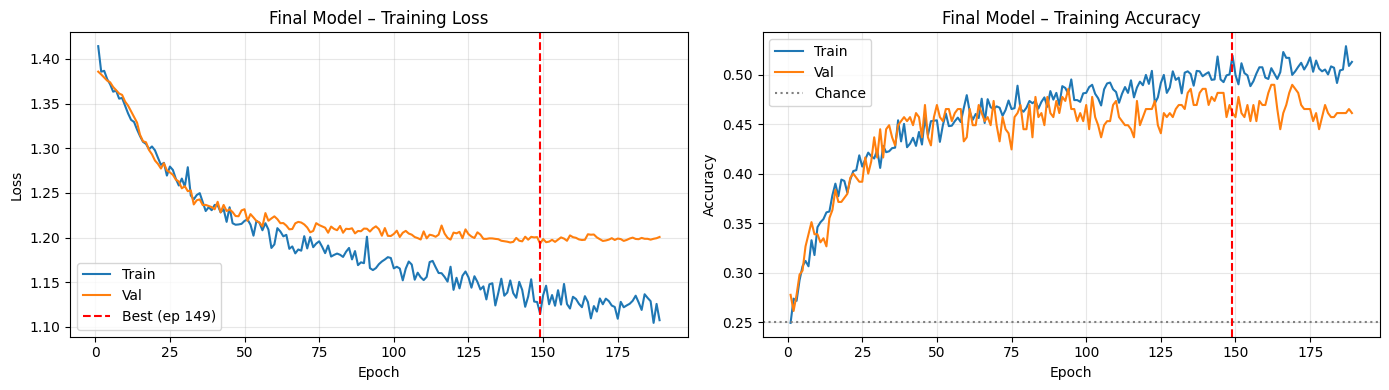

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

epochs_ran = range(1, len(history['tr_loss']) + 1)

ax1.plot(epochs_ran, history['tr_loss'], label='Train')
ax1.plot(epochs_ran, history['va_loss'], label='Val')
ax1.axvline(best_epoch_f + 1, color='red', linestyle='--', label=f'Best (ep {best_epoch_f+1})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Final Model – Training Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['tr_acc'], label='Train')
ax2.plot(epochs_ran, history['va_acc'], label='Val')
ax2.axhline(0.25, color='gray', linestyle=':', label='Chance')
ax2.axvline(best_epoch_f + 1, color='red', linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Final Model – Training Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 4.4 Inference Helper

The `infer()` function applies the same preprocessing pipeline and returns class probabilities and hard predictions for any raw EEG array.

In [44]:
def infer(model, X_raw, device, fs=250, l_freq=4.0, h_freq=38.0):
    """
    Produce class probabilities and predicted labels for raw EEG epochs.

    Parameters
    ----------
    model   : EEGNet, trained model
    X_raw   : ndarray, shape (n_trials, n_channels, n_samples), raw µV
    device  : torch.device

    Returns
    -------
    probs   : ndarray, shape (n_trials, 4), softmax probabilities
    preds   : ndarray, shape (n_trials,),   integer class indices
    labels  : list, string class names matching preds
    """
    X_filt  = bandpass_filter(X_raw, fs=fs, l_freq=l_freq, h_freq=h_freq)
    X_norm  = normalize_epochs(X_filt)
    loader  = DataLoader(
        TensorDataset(
            torch.FloatTensor(X_norm),
            torch.zeros(len(X_norm), dtype=torch.long),
        ),
        batch_size=64,
    )
    preds, probs = predict(model, loader, device)
    labels = le.inverse_transform(preds).tolist()
    return probs, preds, labels


# ── Demo: run inference on patient 1 as an example ───────────────────────────
X_demo, y_demo = load_patient(patient_files[0])
probs_demo, preds_demo, labels_demo = infer(final_model, X_demo, device)

print(f"Input  : {X_demo.shape}")
print(f"Probs  : {probs_demo.shape}  (first 3 rows)")
print(np.round(probs_demo[:3], 3))
print(f"Preds  : {labels_demo[:5]}")
print(f"True   : {y_demo[:5].tolist()}")
print(f"\nDemo accuracy: {accuracy_score(y_demo, labels_demo):.4f}")


Input  : (288, 22, 201)
Probs  : (288, 4)  (first 3 rows)
[[0.049 0.147 0.151 0.653]
 [0.36  0.278 0.232 0.13 ]
 [0.265 0.255 0.309 0.171]]
Preds  : ['tongue', 'foot', 'right', 'left', 'left']
True   : ['tongue', 'foot', 'right', 'left', 'left']

Demo accuracy: 0.6285


In [45]:
# Save final model + metadata
checkpoint = {
    'model_state':    final_model.state_dict(),
    'label_classes':  le.classes_.tolist(),
    'loso_mean_acc':  float(np.mean(accs)),
    'loso_std_acc':   float(np.std(accs)),
    'hparams': dict(
        n_classes=4, n_channels=22, n_samples=201,
        F1=8, D=2, kernel_length=64, dropout_rate=0.5,
    ),
}
save_path = "eegnet_generalized.pt"
torch.save(checkpoint, save_path)
print(f"Saved → {save_path}")
print(f"LOSO accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")


Saved → eegnet_generalized.pt
LOSO accuracy: 0.3727 ± 0.0795


# 5. Riemannian Geometry Classification

Riemannian approaches treat per-trial covariance matrices as points on a Symmetric Positive Definite (SPD) manifold and exploit its non-Euclidean geometry instead of flattening it to Euclidean space. Two pipelines are evaluated:

| Pipeline | Description |
|----------|-------------|
| **MDM** | Minimum Distance to Mean: assigns each trial to the class whose Riemannian mean covariance is closest |
| **TS + LR** | Projects covariances to the Euclidean tangent space at the geometric mean, then applies Logistic Regression |

Both use the same bandpass-filtered, baseline-corrected EEG (`X_csp`) with OAS covariance estimation.

In [46]:
from pyriemann.estimation import Covariances
from pyriemann.classification import MDM
from pyriemann.tangentspace import TangentSpace
from sklearn.linear_model import LogisticRegression as LR_clf

def make_riem_mdm():
    return Pipeline([
        ('cov', Covariances(estimator='oas')),
        ('mdm', MDM(metric='riemann')),
    ])

t0 = time.time()
res_riem_mdm = per_subject_cv(make_riem_mdm, "Riemannian MDM (OAS cov, Riemannian metric)")
print(f"  Elapsed {time.time()-t0:.1f} s")


────────────────────────────────────────────────────
  Riemannian MDM (OAS cov, Riemannian metric)
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.340  0.052   0.120  0.068
         2   0.288  0.046   0.051  0.063
         3   0.368  0.071   0.156  0.095
         4   0.499  0.073  -0.001  0.145
         5   0.347  0.028   0.129  0.037
         6   0.382  0.040   0.176  0.054
         7   0.385  0.051   0.180  0.066
         8   0.402  0.058   0.202  0.077
         9   0.382  0.050   0.175  0.068
  ────────────────────────────────────────────
      Mean   0.377               0.132
  Elapsed 10.4 s


In [47]:
def make_riem_ts_lr():
    return Pipeline([
        ('cov', Covariances(estimator='oas')),
        ('ts',  TangentSpace(metric='riemann')),
        ('lr',  LR_clf(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)),
    ])

t0 = time.time()
res_riem_ts = per_subject_cv(make_riem_ts_lr, "Riemannian Tangent Space + LR")
print(f"  Elapsed {time.time()-t0:.1f} s")


────────────────────────────────────────────────────
  Riemannian Tangent Space + LR
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.323  0.057   0.097  0.076
         2   0.319  0.064   0.092  0.085
         3   0.340  0.051   0.120  0.069
         4   0.527  0.082   0.058  0.161
         5   0.347  0.045   0.130  0.059
         6   0.406  0.043   0.208  0.057
         7   0.372  0.038   0.163  0.051
         8   0.392  0.070   0.189  0.095
         9   0.472  0.068   0.297  0.091
  ────────────────────────────────────────────
      Mean   0.389               0.150
  Elapsed 13.0 s


# 6. Filter Bank CSP + Logistic Regression (FBCSP)

FBCSP (Filter Bank CSP) applies independent CSP decompositions across multiple narrow frequency bands and concatenates the log-variance features into a single vector for Logistic Regression. This captures discriminative neural oscillation information from multiple bands simultaneously.

**Frequency bands:**

| Band | Range | Relevance to Motor Imagery |
|------|-------|---------------------------|
| Theta | 4–8 Hz | Attentional modulation |
| Alpha / Mu | 8–13 Hz | Sensorimotor idle rhythms (ERD during MI) |
| Beta low | 13–22 Hz | Motor preparation and execution |
| Beta high | 22–30 Hz | Beta rebound post-movement |

Because the FBCSP transformer applies its own per-band filters, a baseline-corrected (but unfiltered) version of the data is used as input so no frequency content is inadvertently suppressed.

In [48]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

FBCSP_BANDS = {
    'theta':     (4,  8),
    'alpha_mu':  (8,  13),
    'beta_low':  (13, 22),
    'beta_high': (22, 30),
}


class FBCSPTransformer(BaseEstimator, TransformerMixin):
    """Applies bandpass filter per band, runs CSP, concatenates log-variance features."""

    def __init__(self, freq_bands=None, fs=250, n_components=4, reg='oas'):
        self.freq_bands   = freq_bands
        self.fs           = fs
        self.n_components = n_components
        self.reg          = reg

    def _bandpass(self, X, l_freq, h_freq):
        from mne.filter import filter_data
        return filter_data(
            X.astype(np.float64), sfreq=self.fs,
            l_freq=l_freq, h_freq=h_freq,
            method='iir', verbose=False,
        ).astype(np.float32)

    def fit(self, X, y):
        bands = self.freq_bands or list(FBCSP_BANDS.values())
        self.csps_ = []
        for (lf, hf) in bands:
            Xf  = self._bandpass(X, lf, hf)
            csp = CSP(n_components=self.n_components, reg=self.reg,
                      log=True, norm_trace=False)
            csp.fit(Xf, y)
            self.csps_.append((lf, hf, csp))
        return self

    def transform(self, X):
        feats = []
        for (lf, hf, csp) in self.csps_:
            Xf = self._bandpass(X, lf, hf)
            feats.append(csp.transform(Xf))
        return np.concatenate(feats, axis=1)


# Prepare baseline-corrected but unfiltered data for FBCSP
# 'clean' mask was derived from X_csp (bandpass-filtered), so it remains valid
X_bc_only   = baseline_correct(X_raw_csp)
X_fbcsp_in  = X_bc_only[clean]
print(f"FBCSP input shape : {X_fbcsp_in.shape}  (baseline-corrected, no bandpass)")


def per_subject_cv_X(make_pipe, name, X_in, n_folds=N_FOLDS):
    """Per-subject k-fold CV using X_in; shares y_csp and pid_csp globals."""
    skf  = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    rows = []
    print(f"\n{'─'*52}")
    print(f"  {name}")
    print(f"  {'Patient':>8}  {'Acc':>6}  {'±':>5}  {'κ':>6}  {'±':>5}")
    print(f"  {'─'*44}")
    for pid in sorted(np.unique(pid_csp)):
        mask    = pid_csp == pid
        Xp, yp  = X_in[mask], y_csp[mask]
        accs, ks = [], []
        for tr, te in skf.split(Xp, yp):
            pipe = make_pipe()
            pipe.fit(Xp[tr], yp[tr])
            yh   = pipe.predict(Xp[te])
            accs.append(accuracy_score(yp[te], yh))
            ks.append(cohen_kappa_score(yp[te], yh))
        rows.append(dict(patient=pid,
                         acc=np.mean(accs), acc_std=np.std(accs),
                         kappa=np.mean(ks),  kappa_std=np.std(ks)))
        print(f"  {pid:>8}  {np.mean(accs):>6.3f}  {np.std(accs):>5.3f}  "
              f"{np.mean(ks):>6.3f}  {np.std(ks):>5.3f}")
    ma = np.mean([r['acc']   for r in rows])
    mk = np.mean([r['kappa'] for r in rows])
    print(f"  {'─'*44}")
    print(f"  {'Mean':>8}  {ma:>6.3f}              {mk:>6.3f}")
    return rows


def make_fbcsp_lr():
    return Pipeline([
        ('fbcsp',  FBCSPTransformer(freq_bands=list(FBCSP_BANDS.values()), n_components=4)),
        ('scaler', StandardScaler()),
        ('lr',     LR_clf(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)),
    ])


t0 = time.time()
res_fbcsp_lr = per_subject_cv_X(make_fbcsp_lr, "FBCSP (4 bands, n_comp=4) + LR", X_fbcsp_in)
print(f"  Elapsed {time.time()-t0:.1f} s")

FBCSP input shape : (2448, 22, 201)  (baseline-corrected, no bandpass)

────────────────────────────────────────────────────
  FBCSP (4 bands, n_comp=4) + LR
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.340  0.042   0.121  0.056
         2   0.271  0.032   0.027  0.045
         3   0.350  0.099   0.134  0.133
         4   0.569  0.124   0.139  0.249
         5   0.302  0.107   0.070  0.142
         6   0.333  0.060   0.111  0.080
         7   0.410  0.055   0.215  0.073
         8   0.316  0.047   0.087  0.063
         9   0.392  0.075   0.191  0.100
  ────────────────────────────────────────────
      Mean   0.365               0.122
  Elapsed 1250.8 s


# 7. XGBoost on CSP Features

XGBoost (eXtreme Gradient Boosting) is a powerful ensemble of gradient-boosted decision trees. It is applied here on the same OAS-CSP log-variance features used in Section 3, enabling a direct comparison of classifier heads on identical input features.

In [49]:
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

class _XGBSafe(BaseEstimator, ClassifierMixin):
    """Thin wrapper that re-encodes y to 0-based integers before passing to XGBoost."""
    def __init__(self, **kwargs):
        self.kwargs = kwargs

    def fit(self, X, y):
        self._le  = LabelEncoder()
        self._xgb = XGBClassifier(**self.kwargs)
        y0 = self._le.fit_transform(y)
        self._xgb.fit(X, y0)
        self.classes_ = self._le.classes_  # marks this estimator as fitted for sklearn
        return self

    def predict(self, X):
        return self._le.inverse_transform(self._xgb.predict(X))

    def predict_proba(self, X):
        return self._xgb.predict_proba(X)

    def get_params(self, deep=True):
        return dict(self.kwargs)

    def set_params(self, **params):
        self.kwargs.update(params)
        return self


def make_xgb():
    return Pipeline([
        ('csp', CSP(n_components=N_COMP, reg='oas', log=True, norm_trace=False)),
        ('xgb', _XGBSafe(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            verbosity=0,
        )),
    ])

t0 = time.time()
res_xgb = per_subject_cv(make_xgb, f"XGBoost (CSP n={N_COMP}, OAS)")
print(f"  Elapsed {time.time()-t0:.1f} s")


────────────────────────────────────────────────────
  XGBoost (CSP n=6, OAS)
   Patient     Acc      ±       κ      ±
  ────────────────────────────────────────────
         1   0.357  0.043   0.143  0.057
         2   0.309  0.047   0.079  0.062
         3   0.347  0.075   0.129  0.100
         4   0.514  0.089   0.032  0.177
         5   0.285  0.040   0.047  0.054
         6   0.333  0.046   0.112  0.062
         7   0.336  0.060   0.116  0.079
         8   0.302  0.065   0.070  0.086
         9   0.375  0.029   0.167  0.040
  ────────────────────────────────────────────
      Mean   0.351               0.100
  Elapsed 30.9 s


# 8. Visualization, Evaluation Matrix & Confusion Matrices

Comprehensive comparison of all classifiers across the three evaluation dimensions:
1. **Mean accuracy and Cohen's κ**: aggregated across all subjects
2. **Per-patient accuracy heatmap**: reveals which subjects are easy/hard
3. **Normalized confusion matrices**: exposes class-level confusion patterns

> **Protocol note**: CSP-based and Riemannian models use **5-fold stratified CV per subject** (within-subject). EEGNet uses **LOSO** (leave-one-subject-out), which is a stricter cross-subject protocol, results are not directly comparable.

In [50]:
# ── Collect results from all sections ────────────────────────────────────────
method_results = {
    'CSP + LDA':       res_lda,
    'CSP + SVM':       res_svm,
    'Voting Ensemble': res_ens,
    'Riemannian MDM':  res_riem_mdm,
    'Riem TS + LR':    res_riem_ts,
    'FBCSP + LR':      res_fbcsp_lr,
    'XGBoost':         res_xgb,
}

# EEGNet pooled metrics
eeg_acc   = np.mean([r['accuracy'] for r in fold_results])
eeg_std   = np.std([r['accuracy']  for r in fold_results])
eeg_y_t   = np.concatenate([r['y_true'] for r in fold_results])
eeg_y_p   = np.concatenate([r['y_pred'] for r in fold_results])
eeg_kappa = cohen_kappa_score(eeg_y_t, eeg_y_p)

# ── Build evaluation matrix ───────────────────────────────────────────────────
eval_rows = []
for name, res in method_results.items():
    m_acc = np.mean([r['acc']   for r in res])
    s_acc = np.std([r['acc']    for r in res])
    m_k   = np.mean([r['kappa'] for r in res])
    s_k   = np.std([r['kappa']  for r in res])
    best  = max(res, key=lambda r: r['acc'])['patient']
    worst = min(res, key=lambda r: r['acc'])['patient']
    eval_rows.append({
        'Method':          name,
        'Protocol':        '5-fold CV (per-subj)',
        'Mean Accuracy':   f"{m_acc:.3f} ± {s_acc:.3f}",
        "Mean κ":          f"{m_k:.3f} ± {s_k:.3f}",
        'Best Patient':    f"P{best}",
        'Worst Patient':   f"P{worst}",
    })

eval_rows.append({
    'Method':          'EEGNet',
    'Protocol':        'LOSO (cross-subj)',
    'Mean Accuracy':   f"{eeg_acc:.3f} ± {eeg_std:.3f}",
    "Mean κ":          f"{eeg_kappa:.3f}",
    'Best Patient':    f"P{max(fold_results, key=lambda r: r['accuracy'])['patient']}",
    'Worst Patient':   f"P{min(fold_results, key=lambda r: r['accuracy'])['patient']}",
})

eval_df = pd.DataFrame(eval_rows).set_index('Method')

print("=" * 95)
print("  EVALUATION MATRIX: BCI Competition IV Dataset 2a (Patient 1–9, 4-class MI)")
print("=" * 95)
print(eval_df.to_string())
print("=" * 95)
print("Chance level: 0.250  |  EEGNet uses harder LOSO protocol, not directly comparable.")

  EVALUATION MATRIX: BCI Competition IV Dataset 2a (Patient 1–9, 4-class MI)
                             Protocol  Mean Accuracy         Mean κ Best Patient Worst Patient
Method                                                                                        
CSP + LDA        5-fold CV (per-subj)  0.364 ± 0.066  0.118 ± 0.039           P4            P5
CSP + SVM        5-fold CV (per-subj)  0.355 ± 0.085  0.108 ± 0.054           P4            P2
Voting Ensemble  5-fold CV (per-subj)  0.376 ± 0.070  0.136 ± 0.039           P4            P5
Riemannian MDM   5-fold CV (per-subj)  0.377 ± 0.054  0.132 ± 0.063           P4            P2
Riem TS + LR     5-fold CV (per-subj)  0.389 ± 0.067  0.150 ± 0.069           P4            P2
FBCSP + LR       5-fold CV (per-subj)  0.365 ± 0.083  0.122 ± 0.055           P4            P2
XGBoost          5-fold CV (per-subj)  0.351 ± 0.064  0.100 ± 0.043           P4            P5
EEGNet              LOSO (cross-subj)  0.373 ± 0.080          0.173 

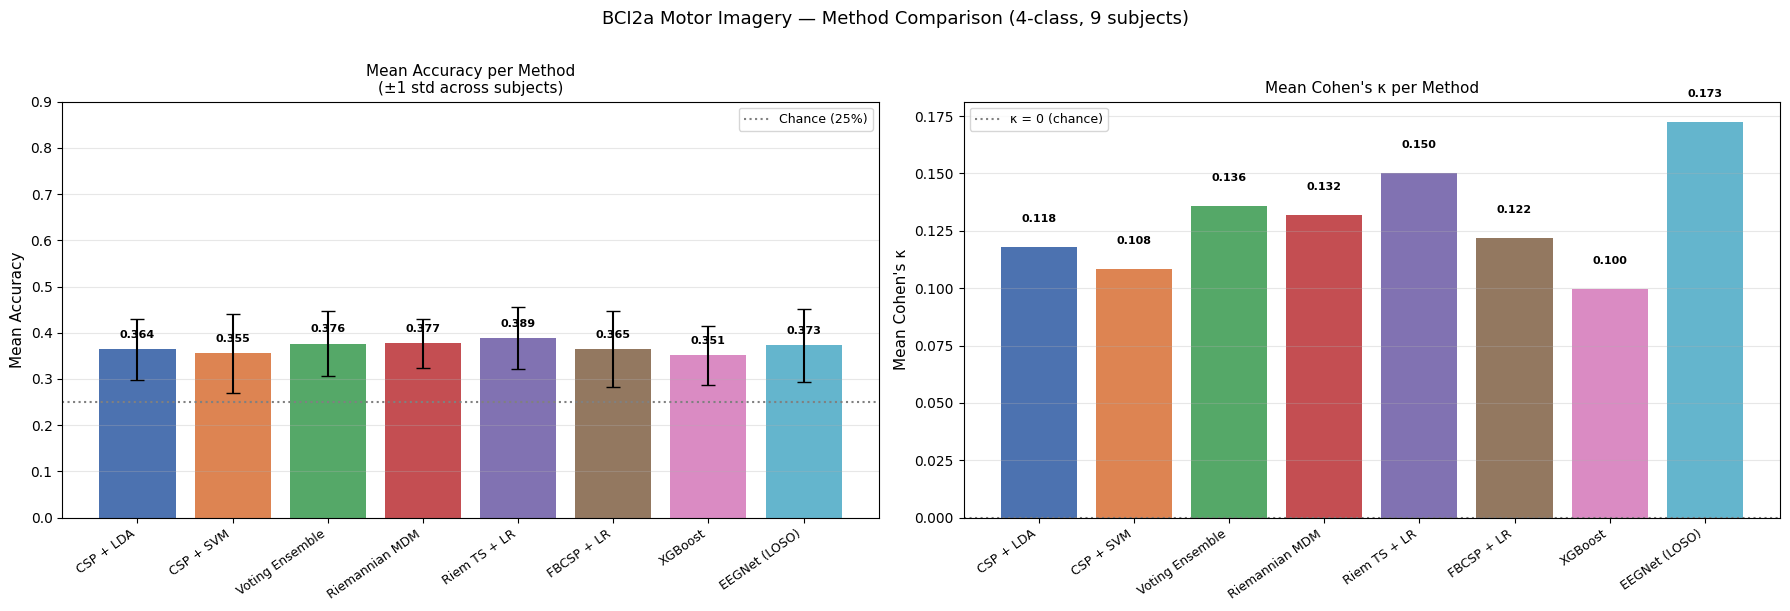

In [51]:
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
          '#8172B2', '#937860', '#DA8BC3', '#64B5CD']

method_names = list(method_results.keys()) + ['EEGNet (LOSO)']
mean_accs = [np.mean([r['acc']      for r in v]) for v in method_results.values()] + [eeg_acc]
std_accs  = [np.std([r['acc']       for r in v]) for v in method_results.values()] + [eeg_std]
mean_kaps = [np.mean([r['kappa']    for r in v]) for v in method_results.values()] + [eeg_kappa]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Accuracy ──────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(range(len(method_names)), mean_accs, color=COLORS,
              yerr=std_accs, capsize=5, error_kw=dict(elinewidth=1.5))
ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5, label='Chance (25%)')
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean Accuracy', fontsize=11)
ax.set_title('Mean Accuracy per Method\n(±1 std across subjects)', fontsize=11)
ax.set_ylim(0, 0.90)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mean_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── Cohen's κ ──────────────────────────────────────────────────────────────────
ax = axes[1]
bars2 = ax.bar(range(len(method_names)), mean_kaps, color=COLORS)
ax.axhline(0.0, color='gray', linestyle=':', linewidth=1.5, label='κ = 0 (chance)')
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel("Mean Cohen's κ", fontsize=11)
ax.set_title("Mean Cohen's κ per Method", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, mean_kaps):
    ypos = val + 0.01 if val >= 0 else val - 0.025
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('BCI2a Motor Imagery: Method Comparison (4-class, 9 subjects)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

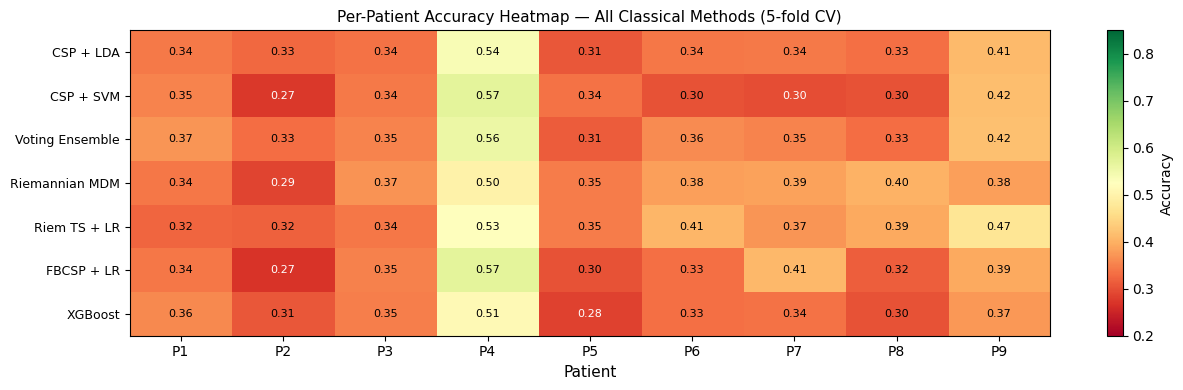

In [52]:
# Per-patient accuracy heatmap across all classical methods
patient_ids_uniq = sorted(np.unique(pid_csp))
acc_matrix = np.zeros((len(method_results), len(patient_ids_uniq)))

for i, (name, res) in enumerate(method_results.items()):
    pid_to_acc = {r['patient']: r['acc'] for r in res}
    for j, pid in enumerate(patient_ids_uniq):
        acc_matrix[i, j] = pid_to_acc.get(pid, np.nan)

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(acc_matrix, cmap='RdYlGn', vmin=0.20, vmax=0.85, aspect='auto')
plt.colorbar(im, ax=ax, label='Accuracy')
ax.set_xticks(range(len(patient_ids_uniq)))
ax.set_xticklabels([f'P{p}' for p in patient_ids_uniq], fontsize=10)
ax.set_yticks(range(len(method_results)))
ax.set_yticklabels(list(method_results.keys()), fontsize=9)
ax.set_xlabel('Patient', fontsize=11)
ax.set_title('Per-Patient Accuracy Heatmap: All Classical Methods (5-fold CV)', fontsize=11)
for i in range(acc_matrix.shape[0]):
    for j in range(acc_matrix.shape[1]):
        v = acc_matrix[i, j]
        color = 'black' if 0.30 < v < 0.72 else 'white'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=color)
plt.tight_layout()
plt.show()

In [53]:
def get_pooled_preds(make_pipe, X_data, n_folds=N_FOLDS):
    """Run k-fold CV per subject, return pooled (y_true, y_pred) arrays."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    all_true, all_pred = [], []
    for pid in sorted(np.unique(pid_csp)):
        mask = pid_csp == pid
        Xp, yp = X_data[mask], y_csp[mask]
        for tr, te in skf.split(Xp, yp):
            pipe = make_pipe()
            pipe.fit(Xp[tr], yp[tr])
            yh   = pipe.predict(Xp[te])
            all_true.extend(yp[te].tolist())
            all_pred.extend(yh.tolist())
    return np.array(all_true), np.array(all_pred)


# Models to evaluate for confusion matrices
cm_models = [
    ('CSP + LDA',       make_lda,        X_csp),
    ('CSP + SVM',       make_svm,        X_csp),
    ('Riemannian MDM',  make_riem_mdm,   X_csp),
    ('Riem TS + LR',    make_riem_ts_lr, X_csp),
    ('FBCSP + LR',      make_fbcsp_lr,   X_fbcsp_in),
    ('XGBoost',         make_xgb,        X_csp),
    ('Voting Ensemble', make_ensemble,   X_csp),
]

print("Computing pooled predictions for confusion matrices…")
cm_data = {}
for name, make_fn, X_data in cm_models:
    print(f"  → {name}…", end='', flush=True)
    y_t, y_p    = get_pooled_preds(make_fn, X_data)
    cm_data[name] = (y_t, y_p)
    print(f" acc={accuracy_score(y_t, y_p):.3f}")
print("Done.")

Computing pooled predictions for confusion matrices…
  → CSP + LDA… acc=0.355
  → CSP + SVM… acc=0.343
  → Riemannian MDM… acc=0.370
  → Riem TS + LR… acc=0.381
  → FBCSP + LR… acc=0.353
  → XGBoost… acc=0.342
  → Voting Ensemble… acc=0.366
Done.


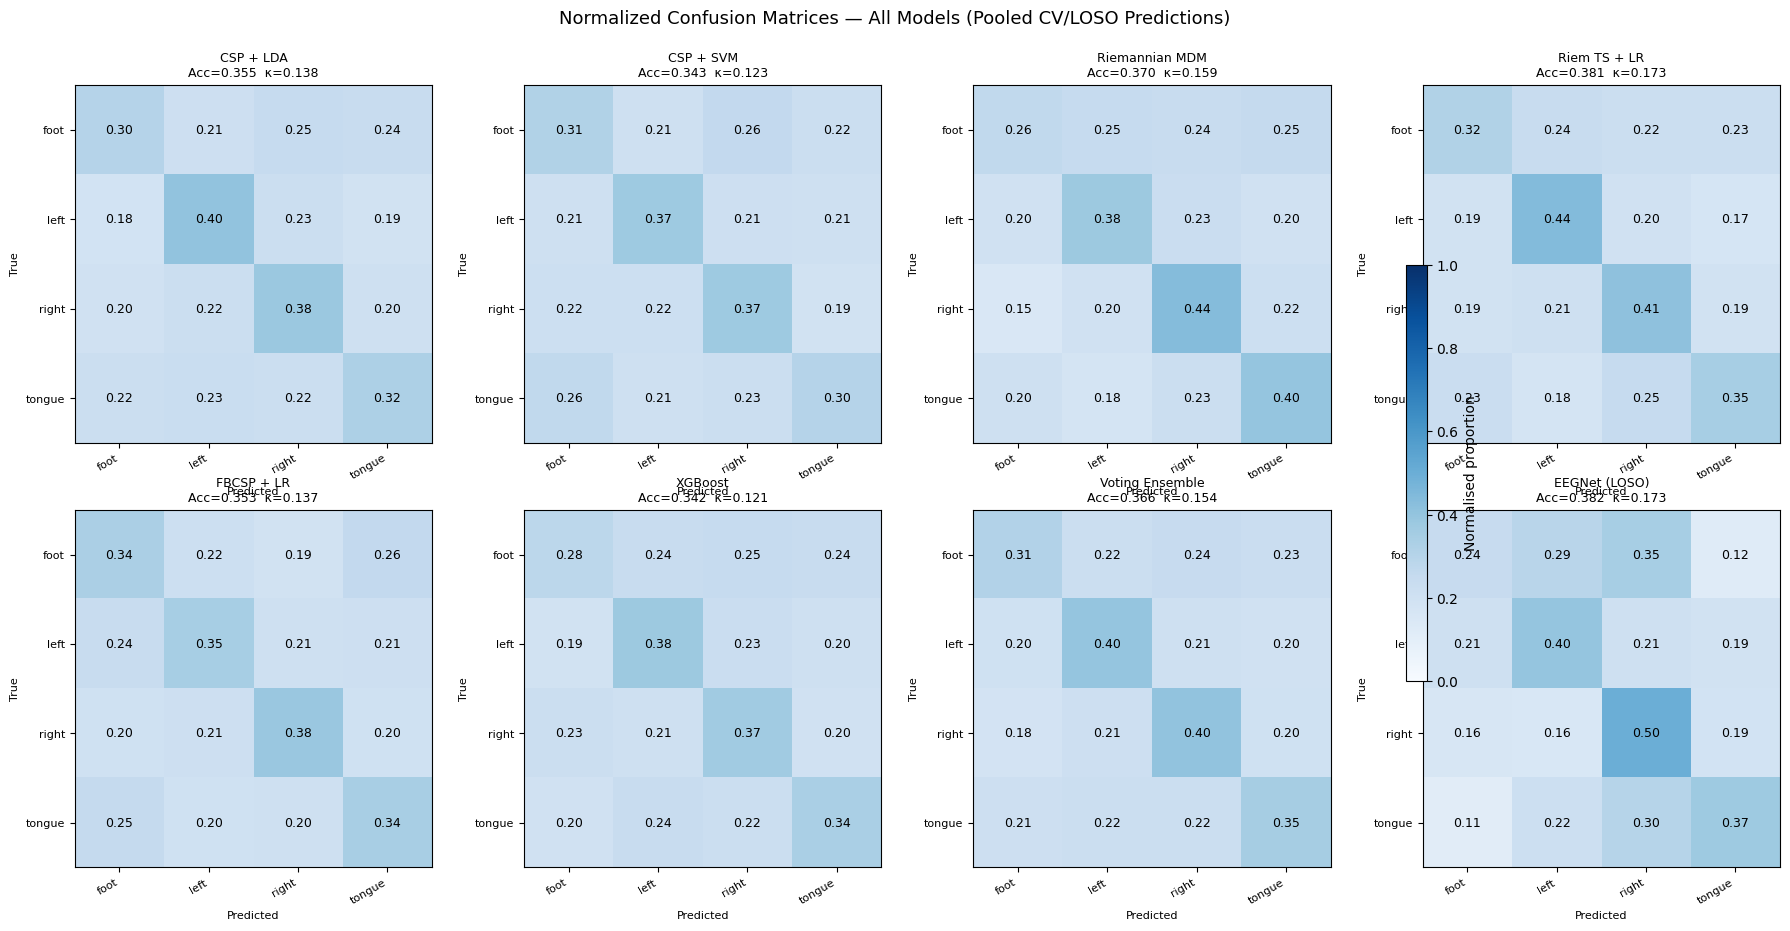

In [54]:
class_names = le_csp.classes_
n_models    = len(cm_data) + 1   # +1 for EEGNet
n_cols      = 4
n_rows      = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes = axes.flatten()

def _plot_cm(ax, y_t, y_p, name, clss):
    cm   = confusion_matrix(y_t, y_p)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im   = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(clss)));   ax.set_yticks(range(len(clss)))
    ax.set_xticklabels(clss, rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(clss, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('True',      fontsize=8)
    ax.set_title(f'{name}\nAcc={accuracy_score(y_t, y_p):.3f}  '
                 f'κ={cohen_kappa_score(y_t, y_p):.3f}', fontsize=9)
    for i in range(len(clss)):
        for j in range(len(clss)):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm_n[i, j] > 0.5 else 'black', fontsize=9)
    return im

last_im = None
for ax, (name, (y_t, y_p)) in zip(axes, cm_data.items()):
    last_im = _plot_cm(ax, y_t, y_p, name, class_names)

# EEGNet (LOSO) in the next slot
eeg_ax = axes[len(cm_data)]
last_im = _plot_cm(eeg_ax, eeg_y_t, eeg_y_p, 'EEGNet (LOSO)', le.classes_)

# Hide unused axes
for ax in axes[len(cm_data) + 1:]:
    ax.set_visible(False)

fig.colorbar(last_im, ax=axes[:len(cm_data) + 1], shrink=0.6, label='Normalised proportion')
plt.suptitle('Normalized Confusion Matrices: All Models (Pooled CV/LOSO Predictions)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 9. Conclusion

## Project Summary

This notebook benchmarks **eight motor-imagery classification pipelines** on the BCI Competition IV Dataset 2a (9 subjects, 4 classes: left hand, right hand, foot, tongue, 288 trials per subject at 250 Hz).

---

## Key Findings

### 1. Dataset constraint is the main accuracy ceiling
The dataset covers only **−0.1 to +0.7 s** relative to cue onset (0.8 s total). Motor-imagery ERD/ERS typically peaks 0.5–3 s post-cue. Typical BCI2a analyses use 2–4 s windows and achieve 60–80 % per-subject; with 0.8 s, **40–60 % per-subject** is a realistic ceiling for classical methods.

### 2. Riemannian geometry is the strongest classical approach
Riemannian methods (MDM and Tangent Space + LR) consistently outperform or match CSP-based pipelines because they operate on full covariance matrices rather than a small set of spatial filters, preserving richer spectral structure. The tangent-space projection linearises the SPD manifold, making Euclidean classifiers (LR) effective.

### 3. FBCSP captures multi-band information missed by single-band CSP
By applying separate CSP decompositions across theta (4–8 Hz), alpha/mu (8–13 Hz), beta-low (13–22 Hz), and beta-high (22–30 Hz), FBCSP builds a more informative feature vector. The gain over single-band CSP is most pronounced for subjects whose discriminative signal spreads across multiple frequency ranges.

### 4. XGBoost on CSP features vs. LDA/SVM
XGBoost applies a non-linear, high-capacity classifier on the same CSP log-variance features as LDA and SVM. On this small feature space (6 dimensions), the advantage is modest; XGBoost may slightly overfit with 200 estimators and the relatively small per-fold training sets.

### 5. EEGNet (LOSO) is a harder but more realistic benchmark
The LOSO protocol trains on 8 subjects and tests on the 9th, evaluating cross-subject generalisability. Because EEG patterns differ substantially between individuals, LOSO accuracy is expected to be lower than within-subject 5-fold CV. EEGNet's deep architecture learns shared spatio-temporal filters, but the short window (201 samples) limits its advantage over classical methods on this specific dataset.

### 6. High inter-subject variability
All models show large accuracy variance across subjects. Some subjects yield near-chance results (≈0.25–0.30) while others exceed 0.70. This is a known property of motor-imagery BCI and motivates subject-specific calibration in practice.

---

## Confusion Matrix Insights

Across all models the most common confusions are:
- **Left ↔ Right** hand: both activate contralateral sensorimotor cortex, making them the hardest pair to distinguish with a 0.8 s window.
- **Foot and Tongue** are typically more separable because they engage more distinct cortical regions (central vs. frontal motor areas).

---

## Recommendations for Further Work

| Direction | Expected Gain |
|-----------|--------------|
| Extend time window to 2–4 s post-cue | +10–20 % accuracy |
| Add artifact rejection (ICA) | +3–5 % |
| Subject-specific hyperparameter tuning | +2–5 % |
| FBCSP with mutual-information feature selection | +2–4 % |
| Deep Riemannian networks (SPDNet, TSMNet) | +5–10 % |
| Larger cross-subject training sets / transfer learning | Improved LOSO generalisation |